# A near-term rainfall projection from CMIP6

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/cmip6_rx1day_projection.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/cmip6_rx1day_projection.ipynb)

**crc-sdk** canonicalizes *any* gridded climate source into the same H3 hazard
curves as JRC floods or ERA5 — including a source it has no built-in recipe for.
This notebook pulls **CMIP6** daily precipitation straight from the
[AWS Open Data registry](https://registry.opendata.aws/cmip6/) (the Pangeo Zarr
mirror, `s3://cmip6-pds`, anonymous) and builds an **Rx1day** baseline for the
US Pacific Northwest from one model, one pathway, one decade:

- **Rx1day**, the wettest day of each year (annual maximum one-day precipitation),
- **GFDL-ESM4**, scenario **ssp585**, member **r1i1p1f1**, **2015-2024**.

1. **Plan** -- find the one dataset in the Pangeo catalogue; open it lazily.
2. **Hazard** -- reduce 10 years of daily precip to 10 *annual maxima per cell*,
   lay them onto a dense H3 grid, and fit a curve per cell with the CRC engine.
3. **Assets** -- read return levels (1-in-2, 1-in-5, 1-in-10) for five cities.
4. **Look closer** -- the 10 annual values behind a wet and a dry curve, and a
   map of the 10-year level that tiles the whole region.

The pattern is the point: a source with no `HazardDataset` recipe still becomes a
canonical dataset through the generic *samples* ingest, after which the portfolio
evaluator works unchanged.

**Workflow:** [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)

## Run the notebook

In Colab, choose **Runtime → Run all**. The setup cell installs the required
packages; the first data read streams ~1 GB of daily precip from S3 and takes a
minute or two, then reduces it to annual maxima.

In [1]:
#@title Install dependencies and prepare this notebook
import importlib.util, subprocess, sys

REQUIREMENTS = [
    "crc-sdk[geometry,netcdf,zarr]>=0.8.0a1", "crc-framework>=0.2.6,<0.3",
    "xarray>=2024.3", "zarr>=2.17,<3", "s3fs>=2024", "h3>=4,<5",
    "numpy>=1.26,<3", "pandas>=2.2,<4", "matplotlib>=3.8", "pyarrow>=16",
]
if importlib.util.find_spec("crc_sdk") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "--disable-pip-version-check", *REQUIREMENTS])
import importlib.metadata as _m
print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {_m.version('crc-sdk')}")

Ready: Python 3.12.7, crc-sdk 0.8.0a1


In [2]:
from pathlib import Path

import fsspec
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import xarray as xr
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon

from crc_sdk.fitting import CDFColumnSchema, CDFCurveFitPolicy, fit_cdf_quantile_batches
from crc_sdk.types import EnsembleDescriptor, SourceProvenance, TemporalWindow
from crc_sdk.workflows import (
    HazardDataset,
    curve_quantiles,
    curve_quantiles_at,
    return_periods_to_probabilities,
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# One model, one pathway, one member, one decade. The Pacific Northwest box.
MODEL, SCENARIO, MEMBER, VARIABLE = "GFDL-ESM4", "ssp585", "r1i1p1f1", "pr"
BOUNDS = (-125.0, 42.0, -116.0, 49.0)  # W, S, E, N
YEARS = (2015, 2024)
# CMIP6 here is a ~1-degree grid; H3 r3 cells are about the same size, so a
# dense r3 tiling of the box matches the source resolution and fills the map.
H3_RES = 3
RETURN_PERIODS = [2, 5, 10]
CITIES = {
    "Seattle": (-122.33, 47.61), "Portland": (-122.68, 45.52),
    "Eugene": (-123.09, 44.05), "Spokane": (-117.43, 47.66),
    "Boise": (-116.20, 43.62),
}

## 1. Plan: one dataset from the catalogue

The Pangeo CMIP6 catalogue (`s3://cmip6-pds/pangeo-cmip6.csv`) lists every
published Zarr store. Filtering to our model, scenario, member and *daily*
precipitation leaves exactly one. `open_zarr` is lazy: this reads only
coordinates and metadata, not the 30 GB of daily fields.

In [3]:
catalog = pd.read_csv("s3://cmip6-pds/pangeo-cmip6.csv",
                      storage_options={"anon": True})
sel = catalog[(catalog.source_id == MODEL) & (catalog.experiment_id == SCENARIO)
              & (catalog.member_id == MEMBER) & (catalog.table_id == "day")
              & (catalog.variable_id == VARIABLE)]
zstore = sel.zstore.iloc[0]
ds = xr.open_zarr(fsspec.get_mapper(zstore, anon=True), consolidated=True)

print(f"store:    {zstore}")
print(f"variable: {VARIABLE} ({ds[VARIABLE].attrs['units']}) -> mm/day via x86400")
print(f"grid:     {ds.lat.size}x{ds.lon.size} ({ds.lat.attrs.get('units','deg')}), "
      f"calendar {ds.time.dt.calendar}")
print(f"coverage: {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]}")

store:    s3://cmip6-pds/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ESM4/ssp585/r1i1p1f1/day/pr/gr1/v20180701/
variable: pr (kg m-2 s-1) -> mm/day via x86400
grid:     180x288 (degrees_north), calendar noleap
coverage: 2015-01-01 to 2100-12-31


## 2. Hazard: annual maxima, fitted per H3 cell

Three moves. **Reduce**: select the box and decade and take the annual maximum of
daily precipitation (mm/day) per grid cell — ten values each. **Place**: tile the
region with H3 cells and give each the maxima of the CMIP6 cell it falls in (the
canonical unit is H3, so a coarse source is regridded onto it). **Fit**: hand the
per-cell *samples* to `fit_cdf_quantile_batches`, which fits a GEV curve (Gumbel
fallback where the short record makes the shape ill-posed, precip censored at 0)
and writes a canonical schema-1.3 file carrying licence, window and ensemble.

In [4]:
# Reduce: Rx1day annual maxima over the box (CMIP6 longitude is 0-360).
W, S, E, N = BOUNDS
box = ds[VARIABLE].sel(
    time=slice(f"{YEARS[0]}-01-01", f"{YEARS[1]}-12-31"),
    lat=slice(S, N), lon=slice(W % 360, E % 360),
)
rx1day = (box * 86400.0).groupby("time.year").max("time").compute()  # (year,lat,lon)
grid = rx1day.to_dataframe(name="rx1day_mm").reset_index()
grid["lon"] = ((grid["lon"] + 180) % 360) - 180
print(f"{grid.year.nunique()} years x "
      f"{grid[['lat','lon']].drop_duplicates().shape[0]} CMIP6 cells "
      f"= {len(grid)} annual maxima")

10 years x 49 CMIP6 cells = 490 annual maxima


In [5]:
# Place: dense H3 tiling of the box; each H3 cell takes the nearest CMIP6 cell.
h3_cells = h3.polygon_to_cells(h3.LatLngPoly([(S, W), (S, E), (N, E), (N, W)]), H3_RES)
src = grid[["lat", "lon"]].drop_duplicates().to_numpy()
samples_by_src = {tuple(k): g["rx1day_mm"].astype(float).tolist()
                  for k, g in grid.groupby(["lat", "lon"])}

rows = []
for cell in h3_cells:
    clat, clon = h3.cell_to_latlng(cell)
    d = (src[:, 0] - clat) ** 2 + ((src[:, 1] - clon) * np.cos(np.radians(clat))) ** 2
    skey = tuple(src[d.argmin()])
    rows.append({"hex_id": h3.str_to_int(cell), "latitude": clat, "longitude": clon,
                 "samples": samples_by_src[skey]})

batch = pa.table({
    "hex_id":     pa.array([r["hex_id"] for r in rows], pa.uint64()),
    "index_name": pa.array(["rx1day"] * len(rows)),
    "year":       pa.array([YEARS[1]] * len(rows), pa.int32()),
    "pathway":    pa.array([SCENARIO] * len(rows)),
    "latitude":   pa.array([r["latitude"] for r in rows], pa.float64()),
    "longitude":  pa.array([r["longitude"] for r in rows], pa.float64()),
    "samples":    pa.array([r["samples"] for r in rows], pa.list_(pa.float64())),
})
print(f"H3 r{H3_RES} cells tiling the box: {len(rows)}")

H3 r3 cells tiling the box: 50


In [6]:
# Fit: GEV with Gumbel fallback, through the CRC engine, to a canonical file.
policy = CDFCurveFitPolicy(
    h3_resolution=H3_RES, family="genextreme", fallback_families=("gumbel_r",),
    lower_bound=0.0, value_unit="mm",
    value_semantics="daily precipitation annual maximum",
    producer="crc-sdk-demo", source_id=f"cmip6-{MODEL}-{SCENARIO}-{MEMBER}".lower(),
    source=SourceProvenance(
        provider="CMIP6 / ScenarioMIP (AWS Open Data, s3://cmip6-pds)",
        dataset=f"{MODEL} {SCENARIO} day {VARIABLE}", uri=zstore,
        version=sel.version.iloc[0].astype(str), licence="CC-BY-4.0",
        attribution="NOAA-GFDL; CMIP6 ScenarioMIP",
    ),
    temporal_window=TemporalWindow(start_year=YEARS[0], end_year=YEARS[1],
                                   calendar="noleap"),
    ensemble=EnsembleDescriptor(pooling="single_member", models=[MODEL],
                                members=[MEMBER], scenario=SCENARIO),
    on_fit_failure="skip", no_data_rate_threshold=None,
)
schema = CDFColumnSchema(cell="hex_id", hazard="index_name", horizon="year",
                         pathway="pathway", samples="samples")

result = fit_cdf_quantile_batches(batch.to_batches(), None, policy, columns=schema)
canonical = result.stream.read_all()
canonical_path = DATA_DIR / "cmip6_pnw_rx1day.parquet"
pq.write_table(canonical, canonical_path)

rx = HazardDataset.local(canonical_path)
meta = rx.metadata()
print(f"{canonical.num_rows} cells fitted; families: "
      f"{dict(result.summary.family_successes)}")
pd.Series({
    "source": meta.source.dataset, "licence": meta.source.licence,
    "window": f"{meta.temporal_window.start_year}-{meta.temporal_window.end_year}",
    "ensemble": f"{meta.ensemble.pooling} ({', '.join(meta.ensemble.models)}, {SCENARIO})",
    "fit": f"{meta.fitting.families[0]}, {meta.fitting.method}",
    "return periods supported": (tuple(round(v, 1) for v in meta.return_period_support)
                                 if meta.return_period_support else "fit range"),
}, name="Rx1day metadata")

50 cells fitted; families: {'genextreme': 50}


source                                 GFDL-ESM4 ssp585 day pr
licence                                              CC-BY-4.0
window                                               2015-2024
ensemble                     single_member (GFDL-ESM4, ssp585)
fit                         genextreme, quantile_least_squares
return periods supported                             fit range
Name: Rx1day metadata, dtype: str

## 3. Assets: return levels at five cities

An ordinary canonical `HazardDataset`, so the portfolio evaluator is unchanged:
each city is matched to its H3 cell and that cell's fitted curve is read at the
requested return periods. Because the region is densely tiled, every city lands
in a populated cell — no nearest-cell snapping needed. A 1-in-10 Rx1day is the
daily rainfall a typical year's wettest day exceeds with 10% probability.

In [7]:
assets = pa.table({
    "asset_id":  list(CITIES),
    "longitude": [lon for lon, _ in CITIES.values()],
    "latitude":  [lat for _, lat in CITIES.values()],
})
levels_path = DATA_DIR / "cmip6_pnw_rx1day_cities.parquet"
rx.for_assets(assets).return_periods(RETURN_PERIODS).write_parquet(levels_path)
levels = pq.read_table(levels_path).to_pandas().set_index("asset_id")
levels = levels[[f"value_rp{rp}" for rp in RETURN_PERIODS]].rename(
    columns={f"value_rp{rp}": f"Rx1day (mm) 1-in-{rp}" for rp in RETURN_PERIODS})
levels.round(1)

,Rx1day (mm) 1-in-2,Rx1day (mm) 1-in-5,Rx1day (mm) 1-in-10
asset_id,,,
Eugene,61.8,70.2,73.8
Boise,23.9,28.7,32.1
Portland,57.2,65.8,69.4
Spokane,41.8,48.8,52.9
Seattle,52.7,60.6,64.8


## 4. Look closer: the 10 values behind a curve, and the map

The dots are each cell's 10 annual maxima at their Gringorten return periods; the
line is the fitted curve read back through the evaluator. A wet coastal cell
(Portland) and a dry interior one (Boise) bracket the range. The map reads one
value per H3 cell — the 10-year Rx1day — and the dense r3 tiling fills the box.

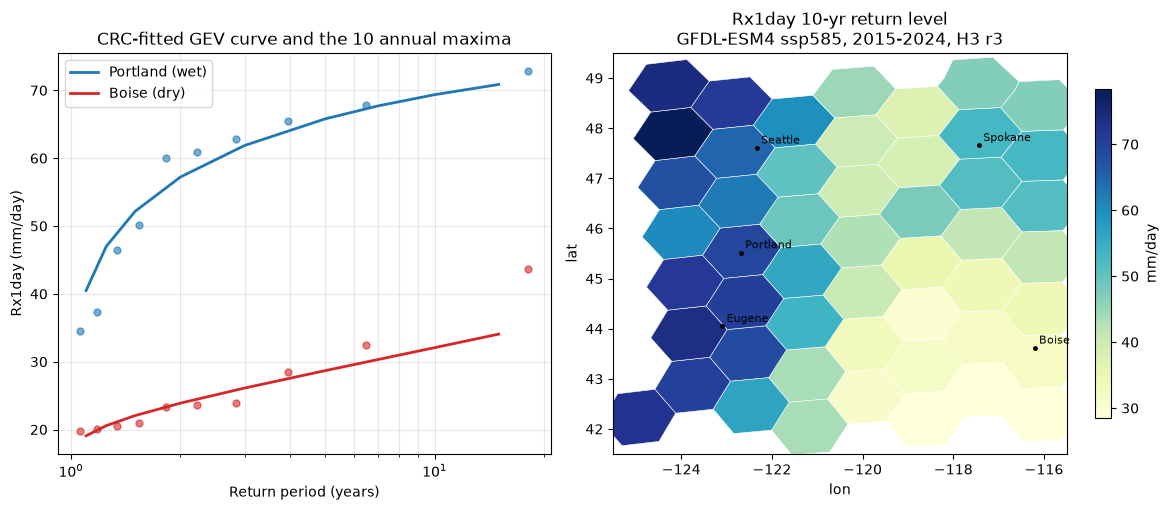

Years most often wettest across the cells: {2024: 11, 2015: 8, 2020: 7, 2022: 7}


In [8]:
prob10 = return_periods_to_probabilities([10], tail=meta.return_period_tail)[0]
cell_ids = np.array(canonical["cell_index"].to_pylist())
rl10 = np.array(curve_quantiles_at(canonical, prob10), dtype=float)
# canonical may skip/reorder failed fits; look up samples by hex, not row index.
samples_by_hex = {r["hex_id"]: r["samples"] for r in rows}

fig, (axc, axm) = plt.subplots(1, 2, figsize=(12, 5.2), width_ratios=[1, 1.15])

# curves: fitted GEV + the 10 annual maxima, wet vs dry
rps = np.array([1.1, 1.25, 1.5, 2, 3, 5, 7, 10, 15])
probs = list(return_periods_to_probabilities(list(rps), tail=meta.return_period_tail))
def gringorten(x):
    x = np.sort(np.asarray(x)); n = x.size; i = np.arange(1, n + 1)
    return 1.0 / (1.0 - (i - 0.44) / (n + 0.12)), x
for name, color in [("Portland", "#1f77b4"), ("Boise", "#d62728")]:
    lon, lat = CITIES[name]
    hx = h3.str_to_int(h3.latlng_to_cell(lat, lon, H3_RES))
    matches = np.where(cell_ids == hx)[0]
    if matches.size == 0:
        continue
    idx = int(matches[0])
    axc.plot(rps, curve_quantiles(canonical.slice(idx, 1), probs)[0], "-",
             color=color, lw=2, label=f"{name} ({'wet' if name=='Portland' else 'dry'})")
    T, v = gringorten(samples_by_hex[hx])
    axc.plot(T, v, "o", color=color, ms=5, alpha=0.6)
axc.set_xscale("log"); axc.set_xlabel("Return period (years)")
axc.set_ylabel("Rx1day (mm/day)"); axc.grid(alpha=0.3, which="both"); axc.legend()
axc.set_title("CRC-fitted GEV curve and the 10 annual maxima")

# map: 10-year level, filled H3 hexagons
patches = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h3.int_to_str(int(c)))])
           for c in cell_ids]
pc = PatchCollection(patches, cmap="YlGnBu", edgecolor="white", linewidths=0.4)
pc.set_array(rl10); axm.add_collection(pc)
axm.set_xlim(W - 0.5, E + 0.5); axm.set_ylim(S - 0.5, N + 0.5)
axm.set_xlabel("lon"); axm.set_ylabel("lat")
for name, (lon, lat) in CITIES.items():
    axm.plot(lon, lat, "k.", ms=5)
    axm.annotate(name, (lon, lat), fontsize=8, xytext=(3, 3), textcoords="offset points")
fig.colorbar(pc, ax=axm, shrink=0.82, label="mm/day")
axm.set_title(f"Rx1day 10-yr return level\n{MODEL} {SCENARIO}, {YEARS[0]}-{YEARS[1]}, H3 r{H3_RES}")
fig.tight_layout(); plt.show()

hottest = grid.loc[grid.groupby(["lat", "lon"])["rx1day_mm"].idxmax(), "year"]
print("Years most often wettest across the cells:",
      {int(y): int(c) for y, c in hottest.value_counts().head(4).items()})

## How to read this, and its limits

- **One model, one member, one scenario.** This is a single CMIP6 realisation of
  `ssp585`, not an ensemble; `ensemble.pooling` records `single_member`. A real
  baseline pools members and models, and the spread between them is itself the
  signal.
- **Ten years is a very short record.** Ten annual maxima barely constrain a
  three-parameter GEV, so the shape is uncertain and levels beyond ~10 years are
  extrapolation; the file's `return_period_support` bounds it. Widen `YEARS` for
  a real fit.
- **A coarse model grid smears terrain.** At ~1 degree a cell is a large area
  average, so a city's value is regional and the rain shadow is softened.
  Rx1day from a climate model also underestimates convective extremes.
- **Projection, not observation.** CMIP6 is a model world; use it for *change*
  signals (compare `historical` with a scenario, or decades within one) rather
  than as a design storm.
- **Provenance travels with the file.** Licence, attribution, source URI, window
  and ensemble are in the Parquet metadata, exactly as for a built-in recipe.

## Scaling this up

Change `MODEL`, `SCENARIO`, `YEARS` or `BOUNDS`, or raise `H3_RES` for a finer
canonical grid. The *samples* ingest is the general lever: any source you can
reduce to per-cell annual extremes — a different CMIP6 variable (`tasmax` for
TXx), a downscaled product, a station network — becomes a canonical
`HazardDataset` the same way. The natural next step is the **historical vs ssp585
delta**: build both and subtract the return levels to get a near-term change map.